In [1]:
import sys
import os
sys.path.append(os.path.abspath(".."))

torch.Size([64, 1, 28, 28])
torch.Size([64])


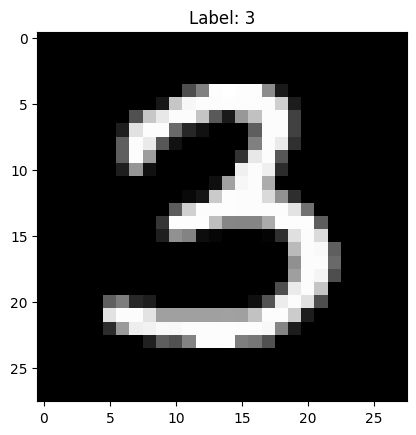

In [2]:
import torch
import matplotlib.pyplot as plt

from src.datasets.mnist import get_mnist_dataloader
from src.models.cnn_denoiser import CNNDenoiser
from src.training.diffusion_forward import prepare_noise_schedule, q_sample_images
from src.training.train_mnist_diffusion import train_mnist_diffusion


In [3]:
dataloader = get_mnist_dataloader(batch_size=64)
images, labels = next(iter(dataloader))

num_steps = 100
_, _, alpha_bars = prepare_noise_schedule(num_steps)

t = torch.randint(0, num_steps, (images.shape[0],))

x_t, noise = q_sample_images(images, t, alpha_bars)


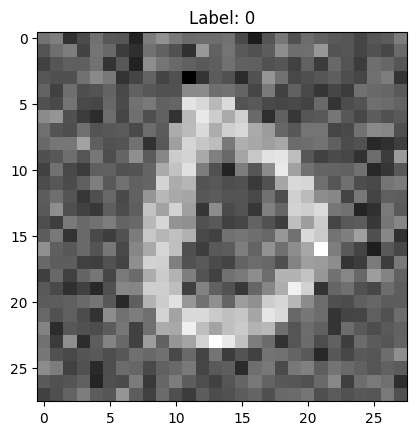

In [4]:
x_t = x_t[0].squeeze().numpy()

plt.imshow(x_t, cmap="gray")
plt.title(f"Label: {labels[0]}")
plt.show()

In [5]:
batch_size = 64
num_steps = 100

dataloader = get_mnist_dataloader(batch_size=batch_size)

_, _, alpha_bars = prepare_noise_schedule(num_steps)

model = CNNDenoiser()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model, losses = train_mnist_diffusion(
    model=model,
    dataloader=dataloader,
    q_sample_images=q_sample_images,
    alpha_bars=alpha_bars,
    num_steps=num_steps,
    epochs=5,
    lr=1e-3,
    device=device
)

Epoch 1/5 - Loss: 0.130309
Epoch 2/5 - Loss: 0.080103
Epoch 3/5 - Loss: 0.075012
Epoch 4/5 - Loss: 0.072137
Epoch 5/5 - Loss: 0.070472


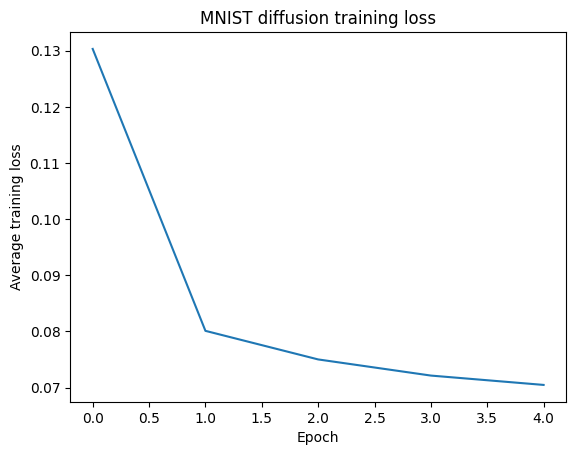

In [6]:
plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("Average training loss")
plt.title("MNIST diffusion training loss")
plt.show()

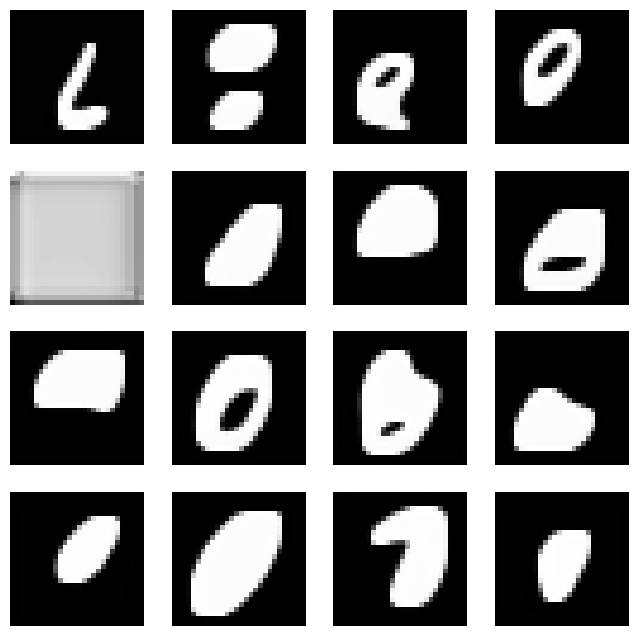

In [8]:
from src.sampling.sample_mnist import sample_images

samples = sample_images(
    model,
    alpha_bars,
    num_steps=100,
    shape=(16, 1, 28, 28),
    device=device
)

samples = samples.cpu()

fig, axes = plt.subplots(4, 4, figsize=(8, 8))
for i, ax in enumerate(axes.flatten()):
    img = samples[i].squeeze().numpy()
    ax.imshow(img, cmap="gray")
    ax.axis("off")